In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from collections import Counter
from scipy import stats
from scipy.stats import shapiro, kruskal, mannwhitneyu

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import StratifiedKFold



import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.sequence import pad_sequences


LABEL2ID = {"ENHANCER": 0, "PROMOTER": 1, "INTERGENIC": 2}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}
LABEL_MAP = ["ENHANCER", "PROMOTER", "INTERGENIC"]

In [8]:
df_balanced = pd.read_parquet("./DNA_dataset/DNA_multiclass_balanced.parquet")

print("\nLabel distribution:")
print(df_balanced["label"].value_counts())

print("\nSequence length statistics:")
print(df_balanced["sequence"].str.len().describe())




Label distribution:
label
2    36131
0    36131
1    36131
Name: count, dtype: int64

Sequence length statistics:
count    108393.000000
mean        249.464698
std         110.516371
min           2.000000
25%         194.000000
50%         251.000000
75%         300.000000
max         573.000000
Name: sequence, dtype: float64


In [9]:
lengths = df_balanced["sequence"].str.len()

groups = [lengths[df_balanced["label"] == i].values for i in range(3)]

# Shapiro-Wilk (normality)
for i, g in enumerate(groups):
    stat, p = shapiro(g[:5000])  # subsample for speed
    print(f"Class {i} Shapiro-Wilk: W={stat:.4f}, p={p:.4e}")

# ANOVA
f_stat, f_p = stats.f_oneway(*groups)
print(f"ANOVA: F={f_stat:.2f}, p={f_p:.4e}")

# Kruskal-Wallis
h_stat, kw_p = kruskal(*groups)
print(f"Kruskal-Wallis: H={h_stat:.2f}, p={kw_p:.4e}")

# Pairwise Mann-Whitney with Bonferroni
pairs = [(0,1),(0,2),(1,2)]
for i,j in pairs:
    u, p = mannwhitneyu(groups[i], groups[j])
    print(f"Class {i} vs {j}: U={u:.0f}, p={p:.4e}")

Class 0 Shapiro-Wilk: W=0.9918, p=2.3036e-16
Class 1 Shapiro-Wilk: W=1.0000, p=1.0000e+00
Class 2 Shapiro-Wilk: W=0.9552, p=1.1414e-36
ANOVA: F=1319.61, p=0.0000e+00
Kruskal-Wallis: H=2332.18, p=0.0000e+00
Class 0 vs 1: U=718157822, p=1.6595e-137
Class 0 vs 2: U=769457772, p=0.0000e+00
Class 1 vs 2: U=748796910, p=5.3214e-294


/Users/omrishlezinger/Documents/biological ML and statistics/.venv/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)


In [4]:
def load_and_analyze(parquet_path):
    print("--- Loading Data ---")
    df = pd.read_parquet(parquet_path, engine='fastparquet')
    
    X = df['sequence'].tolist()
    y = df['label'].values
    
    lengths = [len(s) for s in X]
    limit_95 = int(np.percentile(lengths, 95))
    print(f"Average Length: {np.mean(lengths):.2f}")
    print(f"Max Length in data: {max(lengths)}")
    print(f"95th Percentile Length: {limit_95}") #(Recommended for CNN padding)
    
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=0.15, random_state=42, stratify=y
    )
    
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp
    )
    
    print(f"Dataset Split:")
    print(f"  Train: {len(X_train)} samples")
    print(f"  Val:   {len(X_val)} samples (Static validation)")
    print(f"  Test:  {len(X_test)} samples (Held-out)")
    
    return X_train, X_val, X_test, y_train, y_val, y_test, limit_95

path = '/tf/unified_DNA_dataset/DNA_multiclass_balanced.parquet'
X_train, X_val, X_test, y_train, y_val, y_test, RECOMMENDED_LEN = load_and_analyze(path)

--- Loading Data ---
Average Length: 249.46
Max Length in data: 573
95th Percentile Length: 452
Dataset Split:
  Train: 75918 samples
  Val:   16216 samples (Static validation)
  Test:  16259 samples (Held-out)


In [ ]:
print("\n--- Step 2: SVM Optimization with Optuna ---")
optuna.logging.set_verbosity(optuna.logging.WARNING)

subset_idx = np.random.choice(len(X_train), size=15000, replace=False)
X_train_sub = [X_train[i] for i in subset_idx]
y_train_sub = y_train[subset_idx]

def objective(trial):
    k_mer = trial.suggest_int('k_mer', 3, 6) 
    c_param = trial.suggest_float('C', 1e-3, 10, log=True) 
    
    # K-mer
    vectorizer = CountVectorizer(analyzer='char', ngram_range=(k_mer, k_mer))
    X_vec = vectorizer.fit_transform(X_train_sub)
    
    # Validation
    X_tr, X_val, y_tr, y_val = train_test_split(X_vec, y_train_sub, test_size=0.25, random_state=42)
    
    # LinearSVC (non-linear SVM was way too heavy for tuning on this dataset)
    clf = LinearSVC(C=c_param, dual=False, max_iter=2000)
    clf.fit(X_tr, y_tr)
    
    return clf.score(X_val, y_val)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=15) # מריץ 15 ניסויים

print(f"Best Params: {study.best_params}")

print("\nTraining Final SVM on FULL dataset...")
best_k = study.best_params['k_mer']
best_c = study.best_params['C']

final_vec = CountVectorizer(analyzer='char', ngram_range=(best_k, best_k))
X_train_svm = final_vec.fit_transform(X_train)
X_test_svm = final_vec.transform(X_test)

svm_model = LinearSVC(C=best_c, dual=False, verbose=1)
svm_model.fit(X_train_svm, y_train)

y_pred_svm = svm_model.predict(X_test_svm)
acc_svm = accuracy_score(y_test, y_pred_svm)
print(f"SVM Final Accuracy: {acc_svm:.4f}")


--- Step 2: SVM Optimization with Optuna ---


/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Best Params: {'k_mer': 5, 'C': 0.47768492241426624}

Training Final SVM on FULL dataset...
[LibLinear]iter  1 act 1.326e+04 pre 1.270e+04 delta 2.721e-01 f 3.626e+04 |g| 2.318e+05 CG   4
cg reaches trust region boundary
iter  2 act 1.828e+03 pre 1.678e+03 delta 3.031e-01 f 2.301e+04 |g| 3.232e+04 CG   5
cg reaches trust region boundary
iter  3 act 8.541e+02 pre 8.391e+02 delta 3.163e-01 f 2.118e+04 |g| 1.339e+04 CG   6
cg reaches trust region boundary
iter  4 act 2.590e+02 pre 2.508e+02 delta 3.384e-01 f 2.032e+04 |g| 4.280e+03 CG  13
cg reaches trust region boundary
iter  5 act 1.030e+02 pre 1.036e+02 delta 3.572e-01 f 2.006e+04 |g| 1.606e+03 CG  11
cg reaches trust region boundary
iter  6 act 1.201e+02 pre 1.192e+02 delta 3.726e-01 f 1.996e+04 |g| 1.540e+03 CG  14
cg reaches trust region boundary
iter  7 act 1.115e+02 pre 1.123e+02 delta 3.895e-01 f 1.984e+04 |g| 1.682e+03 CG  15
cg reaches trust region boundary
iter  8 act 1.046e+02 pre 1.036e+02 delta 4.174e-01 f 1.973e+04 |g| 1.31

In [6]:
print(f"SVM Final Accuracy: {acc_svm:.4f}")

SVM Final Accuracy: 0.7293


In [ ]:
# --- 1. Preprocessing Functions ---
DNA_DICT = {'A': 0, 'C': 1, 'G': 2, 'T': 3, 'N': 4} 

def encode_and_pad(sequences, max_len):
    encoded_list = []
    for seq in sequences:
        num_seq = [DNA_DICT.get(base, 4) for base in seq] 
        encoded_list.append(num_seq)
    # Padding
    return pad_sequences(encoded_list, maxlen=max_len, padding='post', truncating='post', value=4)

# --- 2. Augmentation Functions ---
def augment_dna_simple(seq_ohe, label):
    """Adds noise to DNA sequence for robustness"""
    seq_ohe = tf.cast(seq_ohe, tf.float32)
    noise = tf.random.normal(tf.shape(seq_ohe), mean=0.0, stddev=0.02, dtype=tf.float32)
    seq_ohe = seq_ohe + noise
    seq_ohe = tf.clip_by_value(seq_ohe, 0.0, 1.0)
    return seq_ohe, label

def create_augmented_dataset(X, y, batch_size=32, augment=True, shuffle=True):
    # Ensure correct types
    X = X.astype(np.float32)
    y = y.astype(np.float32)
    
    dataset = tf.data.Dataset.from_tensor_slices((X, y))
    
    if shuffle:
        dataset = dataset.shuffle(buffer_size=10000, reshuffle_each_iteration=True)
    
    if augment:
        dataset = dataset.map(augment_dna_simple, num_parallel_calls=tf.data.AUTOTUNE)
    
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset

# --- 3. Model Definition ---
def build_dna_cnn_robust(seq_length, num_classes=3):
    model = models.Sequential([
        layers.Input(shape=(seq_length, 5)),
        
        layers.GaussianNoise(0.1),
        
        layers.Conv1D(filters=32, kernel_size=12, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l1_l2(l1=0.0001, l2=0.001)),
        layers.BatchNormalization(),
        layers.SpatialDropout1D(0.2),
        layers.MaxPooling1D(pool_size=4),
        
        layers.Conv1D(filters=64, kernel_size=8, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l1_l2(l1=0.0001, l2=0.001)),
        layers.BatchNormalization(),
        layers.SpatialDropout1D(0.3),
        layers.MaxPooling1D(pool_size=4),
        
        layers.Conv1D(filters=32, kernel_size=6, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l1_l2(l1=0.0001, l2=0.001)),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling1D(),
        
        layers.Dense(64, activation='relu',
                    kernel_regularizer=tf.keras.regularizers.l1_l2(l1=0.0001, l2=0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        
        layers.Dense(num_classes, activation='softmax')
    ])
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003, clipnorm=1.0),
        loss='categorical_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model
print("All functions defined successfully.")

2026-02-04 20:06:42.756140: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-04 20:06:43.113291: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/usr/local/lib/python3.11/dist-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
/usr/local/lib/python3.11/dist

All functions defined successfully.


In [ ]:

FINAL_LEN = max(RECOMMENDED_LEN, 200)

# Cross Validation
X_cv_raw = X_train + X_val
y_cv_raw = np.concatenate([y_train, y_val])

print("Encoding data...")
X_cv_padded = encode_and_pad(X_cv_raw, FINAL_LEN)
X_test_padded = encode_and_pad(X_test, FINAL_LEN)

# One-Hot
X_cv_ohe = tf.one_hot(X_cv_padded, depth=5).numpy()
X_test_ohe = tf.one_hot(X_test_padded, depth=5).numpy()
y_test_cat = tf.keras.utils.to_categorical(y_test, num_classes=3)

# Cross-Validation
n_splits = 5
kfold = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
cv_scores = []
best_val_acc = 0
best_model = None

Encoding data...


I0000 00:00:1770235607.589819  161020 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4419 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:03:00.0, compute capability: 8.6


In [ ]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

# Batch Size
BATCH_SIZE = 128 

print(f"\n--- Starting {n_splits}-Fold Cross-Validation ---\n")

for i, (train_idx, val_idx) in enumerate(kfold.split(X_cv_ohe, y_cv_raw)):
    print(f"\nTraining Fold {i+1}/{n_splits}...") # ירידת שורה לבהירות
    
    # Fold
    X_f_tr, X_f_val = X_cv_ohe[train_idx], X_cv_ohe[val_idx]
    y_f_tr, y_f_val = y_cv_raw[train_idx], y_cv_raw[val_idx]
    
    # Categorical
    y_f_tr_cat = tf.keras.utils.to_categorical(y_f_tr, num_classes=3)
    y_f_val_cat = tf.keras.utils.to_categorical(y_f_val, num_classes=3)
    
    train_ds = create_augmented_dataset(X_f_tr, y_f_tr_cat, batch_size=BATCH_SIZE, augment=True)
    val_ds = create_augmented_dataset(X_f_val, y_f_val_cat, batch_size=BATCH_SIZE, augment=False, shuffle=False)
    

    model = build_dna_cnn_robust(seq_length=FINAL_LEN, num_classes=3)
    
    # Callbacks
    fold_callbacks = [
        callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True), # קיצרתי מעט patience
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
    ]
    
    # verbose=1
    history = model.fit(
        train_ds, validation_data=val_ds,
        epochs=10, 
        callbacks=fold_callbacks,
        verbose=1  # שינוי קריטי: כעת תראה את ההתקדמות
    )
    
    scores = model.evaluate(val_ds, verbose=0)
    acc = scores[1]
    cv_scores.append(acc)
    print(f"Fold {i+1} Finished. Val Acc: {acc:.4f}")
    
    if acc > best_val_acc:
        best_val_acc = acc
        best_model = model

print(f"\nAverage CV Accuracy: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})")

Num GPUs Available:  1

--- Starting 5-Fold Cross-Validation ---


Training Fold 1/5...
Epoch 1/10


2026-02-04 20:06:53.596461: I external/local_xla/xla/service/service.cc:163] XLA service 0x7fd7a00148a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-04 20:06:53.596481: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3090, Compute Capability 8.6
2026-02-04 20:06:53.681793: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-02-04 20:06:54.290612: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002
2026-02-04 20:06:54.619469: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-02-04 20:06:54.619547: I e

 51/576 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3691 - auc: 0.5419 - loss: 1.9723

I0000 00:00:1770235619.993926  161133 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


567/576 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5156 - auc: 0.7002 - loss: 1.4782

...

576/576 ━━━━━━━━━━━━━━━━━━━━ 20s 18ms/step - accuracy: 0.5947 - auc: 0.7788 - loss: 1.2441 - val_accuracy: 0.7001 - val_auc: 0.8658 - val_loss: 0.9674 - learning_rate: 3.0000e-04
Epoch 2/10
576/576 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7157 - auc: 0.8821 - loss: 0.9108 - val_accuracy: 0.8064 - val_auc: 0.9343 - val_loss: 0.7406 - learning_rate: 3.0000e-04
Epoch 3/10
576/576 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7984 - auc: 0.9343 - loss: 0.7134 - val_accuracy: 0.8743 - val_auc: 0.9720 - val_loss: 0.5322 - learning_rate: 3.0000e-04
Epoch 4/10
576/576 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8570 - auc: 0.9631 - loss: 0.5570 - val_accuracy: 0.8915 - val_auc: 0.9783 - val_loss: 0.4569 - learning_rate: 3.0000e-04
Epoch 5/10
576/576 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8755 - auc: 0.9709 - loss: 0.4859 - val_accuracy: 0.8963 - val_auc: 0.9801 - val_loss: 0.4175 - learning_rate: 3.0000e-04
Epoch 6/10
576/576 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.882

2026-02-04 20:09:28.047595: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-02-04 20:09:28.047679: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-02-04 20:09:28.912355: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3912', 108 bytes spill stores, 108 bytes spill loads

2026-02-04 20:09:28.934819: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning

576/576 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5123 - auc: 0.7001 - loss: 1.4805

2026-02-04 20:09:33.044896: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'loop_add_subtract_fusion_3', 8 bytes spill stores, 8 bytes spill loads

2026-02-04 20:09:34.577053: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-02-04 20:09:34.959022: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_325', 36 bytes spill stores, 36 bytes spill loads

2026-02-04 20:09:35.098515: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_325', 200

576/576 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - accuracy: 0.5910 - auc: 0.7781 - loss: 1.2533 - val_accuracy: 0.6527 - val_auc: 0.8543 - val_loss: 0.9964 - learning_rate: 3.0000e-04
Epoch 2/10
576/576 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7233 - auc: 0.8858 - loss: 0.9026 - val_accuracy: 0.8134 - val_auc: 0.9333 - val_loss: 0.7540 - learning_rate: 3.0000e-04
Epoch 3/10
576/576 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8004 - auc: 0.9350 - loss: 0.7090 - val_accuracy: 0.8849 - val_auc: 0.9767 - val_loss: 0.5121 - learning_rate: 3.0000e-04
Epoch 4/10
576/576 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8641 - auc: 0.9663 - loss: 0.5371 - val_accuracy: 0.8985 - val_auc: 0.9804 - val_loss: 0.4388 - learning_rate: 3.0000e-04
Epoch 5/10
576/576 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8826 - auc: 0.9733 - loss: 0.4674 - val_accuracy: 0.9031 - val_auc: 0.9825 - val_loss: 0.3955 - learning_rate: 3.0000e-04
Epoch 6/10
576/576 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.888

--- Final Evaluation using the BEST Model found in CV ---
Available metrics keys: ['loss', 'compile_metrics']

Test Results:
  Loss:      0.2929
  Accuracy:  N/A (Could not find accuracy metric)

Generating predictions...


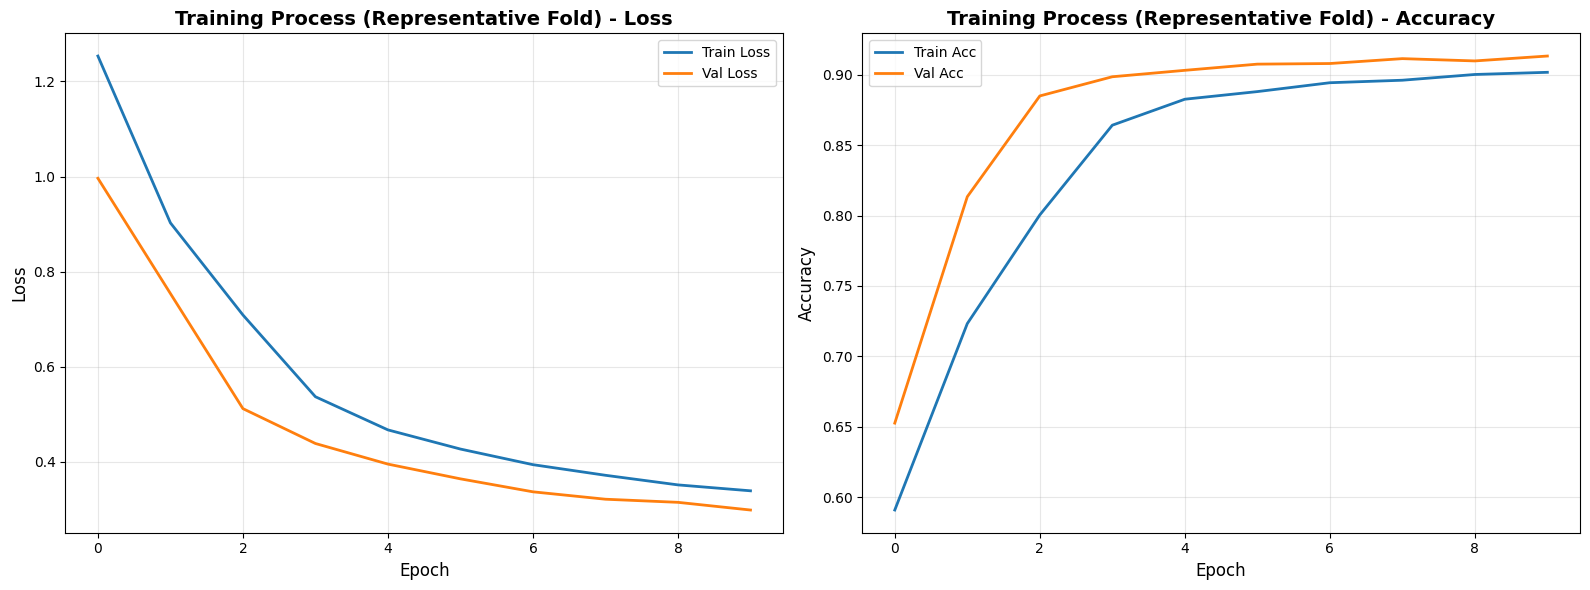


Classification Report:
              precision    recall  f1-score   support

    ENHANCER     0.8785    0.8808    0.8797      5419
    PROMOTER     0.9826    1.0000    0.9912      5420
  INTERGENIC     0.8881    0.8701    0.8790      5420

    accuracy                         0.9170     16259
   macro avg     0.9164    0.9170    0.9166     16259
weighted avg     0.9164    0.9170    0.9166     16259



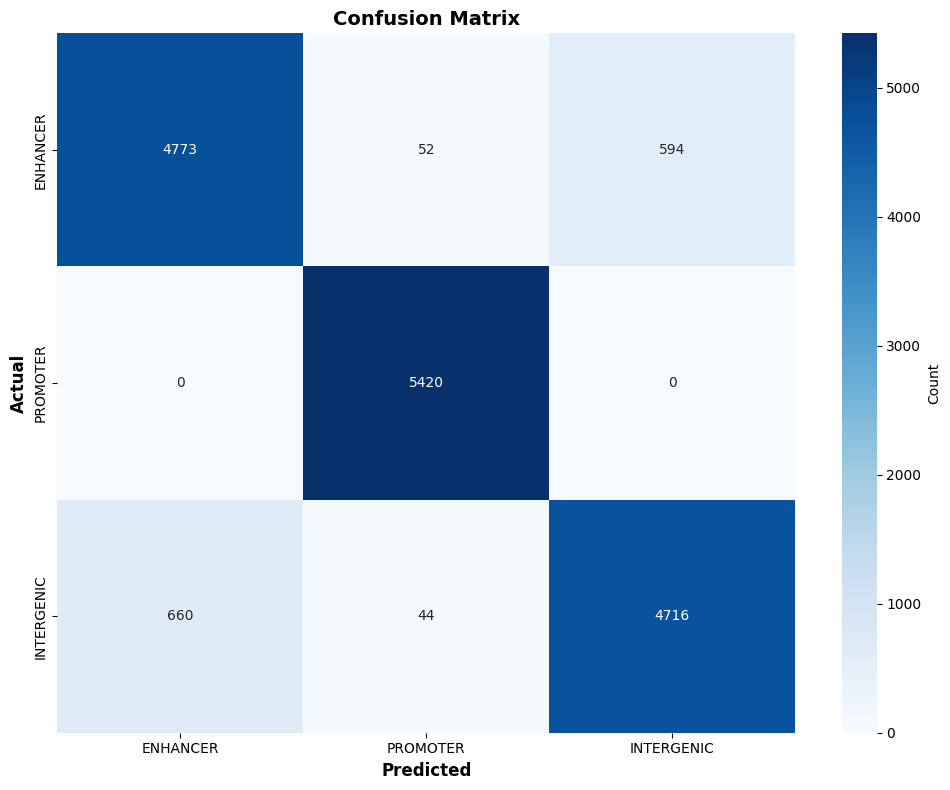

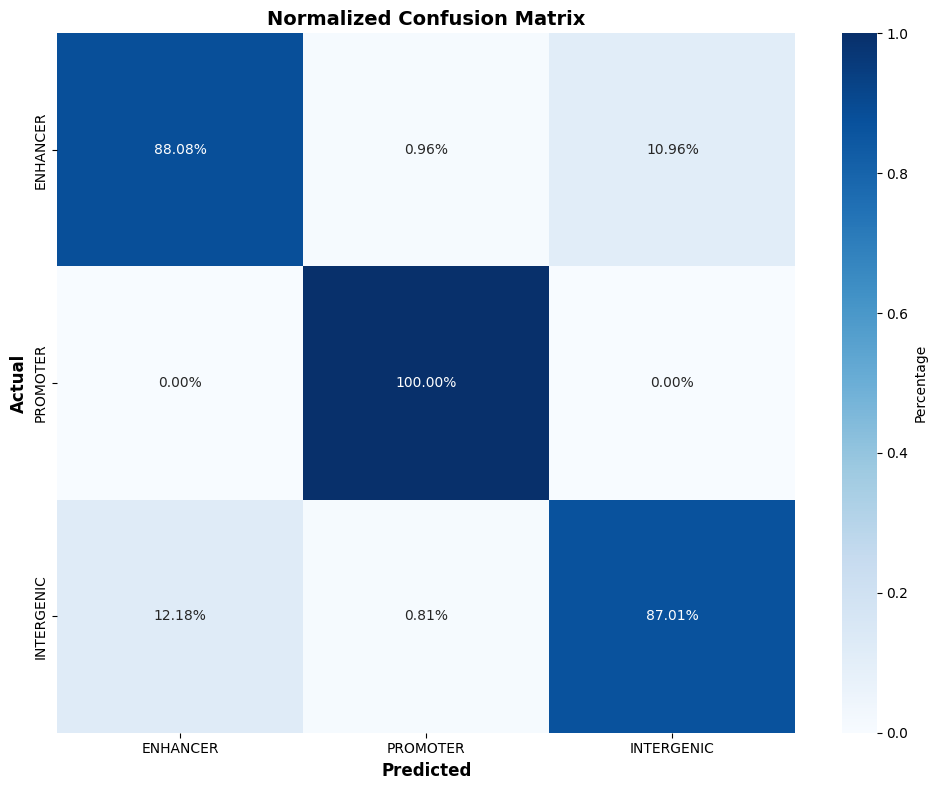


Per-Class Accuracy Analysis:
  ENHANCER: 88.08% (5419 samples)
  PROMOTER: 100.00% (5420 samples)
  INTERGENIC: 87.01% (5420 samples)

Sample Predictions (Random Sample):
  ✓ True: PROMOTER     | Predicted: PROMOTER     | Confidence: 99.67%
  ✓ True: ENHANCER     | Predicted: ENHANCER     | Confidence: 86.18%
  ✓ True: PROMOTER     | Predicted: PROMOTER     | Confidence: 99.74%
  ✓ True: ENHANCER     | Predicted: ENHANCER     | Confidence: 97.68%
  ✓ True: ENHANCER     | Predicted: ENHANCER     | Confidence: 99.09%
  ✓ True: INTERGENIC   | Predicted: INTERGENIC   | Confidence: 95.43%
  ✓ True: PROMOTER     | Predicted: PROMOTER     | Confidence: 99.81%
  ✓ True: PROMOTER     | Predicted: PROMOTER     | Confidence: 99.65%
  ✓ True: ENHANCER     | Predicted: ENHANCER     | Confidence: 99.61%
  ✓ True: PROMOTER     | Predicted: PROMOTER     | Confidence: 99.78%


In [ ]:
print(f"--- Final Evaluation using the BEST Model found in CV ---")

# 1. Evaluate on test set using the BEST model found during CV
test_results = best_model.evaluate(X_test_ohe, y_test_cat, verbose=0)

# Create a dictionary of metrics
test_metrics = dict(zip(best_model.metrics_names, test_results))

print(f"Available metrics keys: {list(test_metrics.keys())}")

print(f"\nTest Results:")
print(f"  Loss:      {test_metrics['loss']:.4f}")

# --- Accuracy ---
acc_key = next((k for k in test_metrics.keys() if 'acc' in k), None)

if acc_key:
    print(f"  Accuracy:  {test_metrics[acc_key]:.4f}")
else:
    print("  Accuracy:  N/A (Could not find accuracy metric)")

if 'auc' in test_metrics:
    print(f"  AUC:       {test_metrics['auc']:.4f}")

# 2. Make predictions
print("\nGenerating predictions...")
predictions = best_model.predict(X_test_ohe, verbose=0)
predicted_classes = predictions.argmax(axis=1)
y_test_classes = y_test_cat.argmax(axis=1)

# 3. Plot training history (Of the LAST Fold)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

if 'loss' in history.history:
    # Loss
    axes[0].plot(history.history['loss'], label='Train Loss', linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title('Training Process (Representative Fold) - Loss', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)

    hist_acc_key = next((k for k in history.history.keys() if 'acc' in k and 'val' not in k), None)
    hist_val_acc_key = next((k for k in history.history.keys() if 'val_' in k and 'acc' in k), None)
    
    if hist_acc_key and hist_val_acc_key:
        axes[1].plot(history.history[hist_acc_key], label='Train Acc', linewidth=2)
        axes[1].plot(history.history[hist_val_acc_key], label='Val Acc', linewidth=2)
        axes[1].set_xlabel('Epoch', fontsize=12)
        axes[1].set_ylabel('Accuracy', fontsize=12)
        axes[1].set_title('Training Process (Representative Fold) - Accuracy', fontsize=14, fontweight='bold')
        axes[1].legend(fontsize=10)
        axes[1].grid(True, alpha=0.3)
else:
    print("Warning: No training history available to plot.")

plt.tight_layout()
plt.show()

# 4. Classification Report
class_names = ['ENHANCER', 'PROMOTER', 'INTERGENIC']

print("\nClassification Report:")
print(classification_report(
    y_test_classes, 
    predicted_classes,
    target_names=class_names,
    digits=4
))

# 5. Confusion Matrix
cm = confusion_matrix(y_test_classes, predicted_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    cbar_kws={'label': 'Count'}
)
plt.xlabel('Predicted', fontsize=12, fontweight='bold')
plt.ylabel('Actual', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 6. Normalized confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_normalized, 
    annot=True, 
    fmt='.2%', 
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    cbar_kws={'label': 'Percentage'}
)
plt.xlabel('Predicted', fontsize=12, fontweight='bold')
plt.ylabel('Actual', fontsize=12, fontweight='bold')
plt.title('Normalized Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 7. Per-class performance analysis
print("\nPer-Class Accuracy Analysis:")
for i, class_name in enumerate(class_names):
    class_mask = (y_test_classes == i)
    if class_mask.sum() > 0:
        class_acc = (predicted_classes[class_mask] == i).sum() / class_mask.sum()
        print(f"  {class_name}: {class_acc:.2%} ({class_mask.sum()} samples)")
    else:
        print(f"  {class_name}: No samples in test set")

# 8. Show some example predictions
print("\nSample Predictions (Random Sample):")
random_indices = np.random.choice(len(predicted_classes), 10, replace=False)
for i in random_indices:
    true_class = class_names[y_test_classes[i]]
    pred_class = class_names[predicted_classes[i]]
    confidence = predictions[i][predicted_classes[i]]
    match = "✓" if y_test_classes[i] == predicted_classes[i] else "✗"
    print(f"  {match} True: {true_class:12s} | Predicted: {pred_class:12s} | Confidence: {confidence:.2%}")


--- Final Comparison: SVM vs. CNN (Held-out Test Set) ---
Training SVM on full training data...


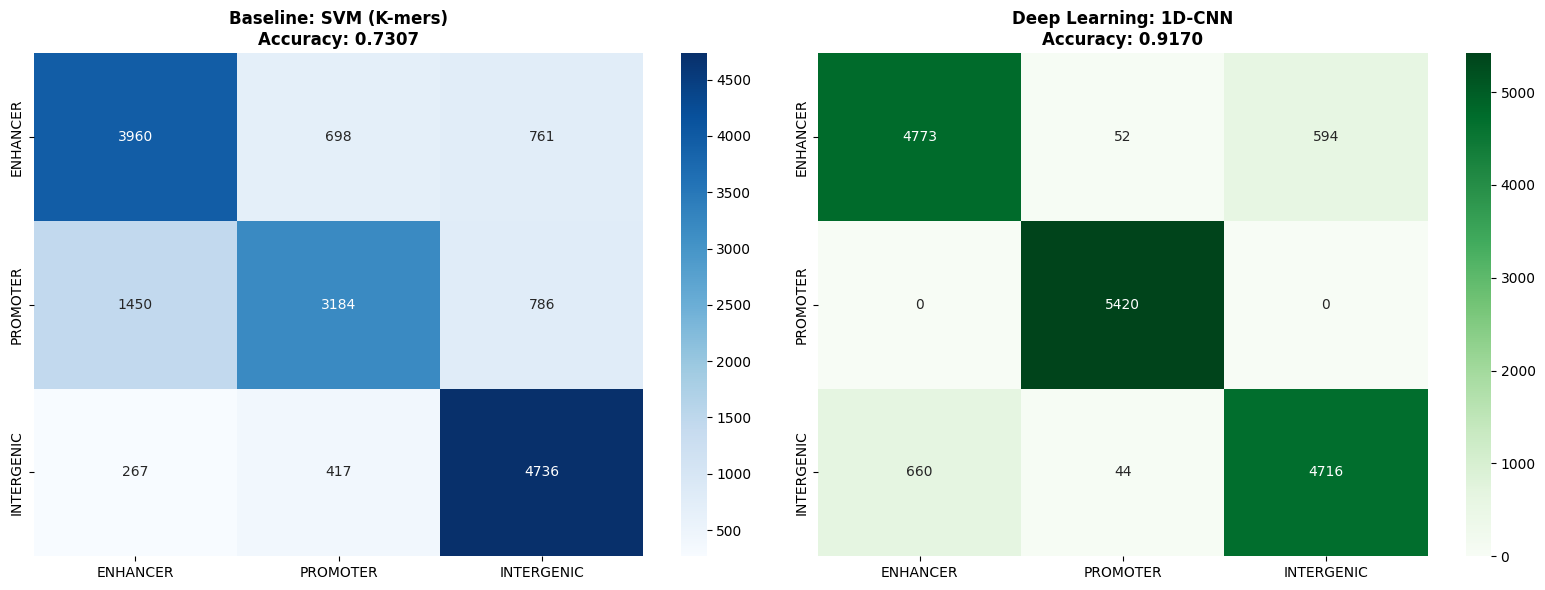


Final Result Summary:
SVM Accuracy: 73.07%
CNN Accuracy: 91.70%
Improvement:  +25.50%

--- Detailed Report (CNN) ---
              precision    recall  f1-score   support

    ENHANCER     0.8785    0.8808    0.8797      5419
    PROMOTER     0.9826    1.0000    0.9912      5420
  INTERGENIC     0.8881    0.8701    0.8790      5420

    accuracy                         0.9170     16259
   macro avg     0.9164    0.9170    0.9166     16259
weighted avg     0.9164    0.9170    0.9166     16259



In [ ]:
print("\n--- Final Comparison: SVM vs. CNN (Held-out Test Set) ---")

print("Training SVM on full training data...")
X_train_full_raw = X_train + X_val  # איחוד רשימות
y_train_full = np.concatenate([y_train, y_val])


k_mer_size = 5 
vectorizer = CountVectorizer(analyzer='char', ngram_range=(k_mer_size, k_mer_size))
X_train_vec = vectorizer.fit_transform(X_train_full_raw)
X_test_vec = vectorizer.transform(X_test) # המרת ה-Test Set

# SVM
svm_model.fit(X_train_vec, y_train_full)

y_pred_svm = svm_model.predict(X_test_vec)
acc_svm = accuracy_score(y_test, y_pred_svm)

y_pred_cnn_probs = best_model.predict(X_test_ohe, verbose=0)
y_pred_cnn = np.argmax(y_pred_cnn_probs, axis=1)
acc_cnn = accuracy_score(y_test, y_pred_cnn)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
labels = ['ENHANCER', 'PROMOTER', 'INTERGENIC']

# SVM Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title(f'Baseline: SVM (K-mers)\nAccuracy: {acc_svm:.4f}', fontsize=12, fontweight='bold')

# CNN Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_cnn), annot=True, fmt='d', cmap='Greens',
            xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title(f'Deep Learning: 1D-CNN\nAccuracy: {acc_cnn:.4f}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


print(f"\nFinal Result Summary:")
print(f"SVM Accuracy: {acc_svm:.2%}")
print(f"CNN Accuracy: {acc_cnn:.2%}")
improvement = (acc_cnn - acc_svm) / acc_svm * 100
print(f"Improvement:  {improvement:+.2f}%")

print("\n--- Detailed Report (CNN) ---")
print(classification_report(y_test, y_pred_cnn, target_names=labels, digits=4))


--- Model Interpretability Analysis ---
Visualizing weights from layer: conv1d_12


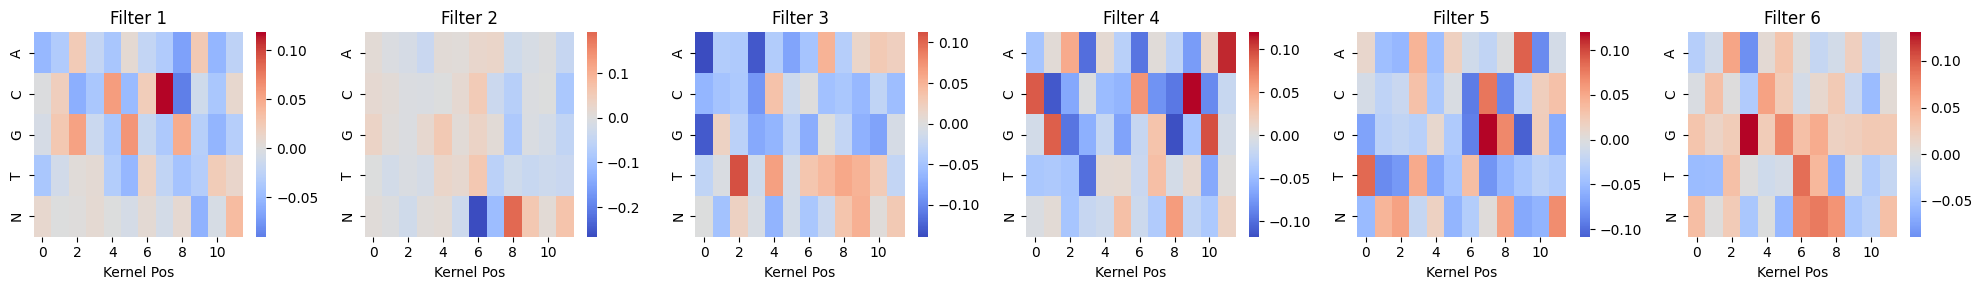

Generating Saliency Map for sample 10 (Class: ENHANCER)...


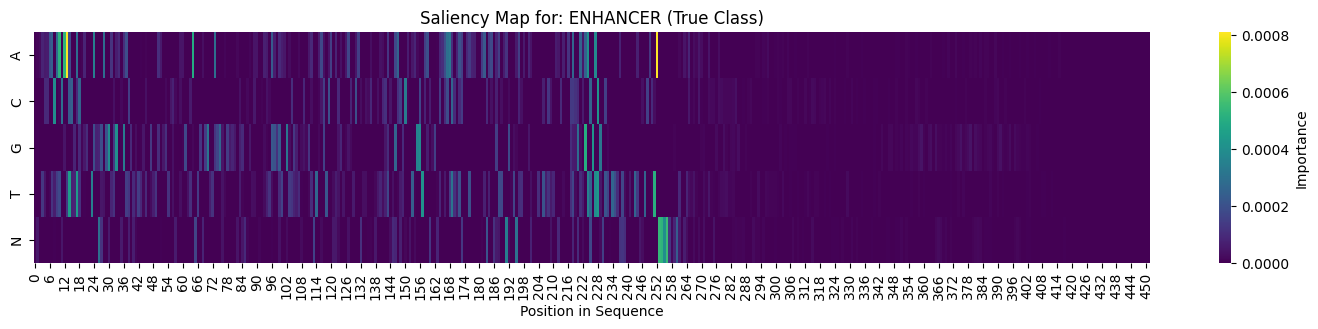

In [ ]:
def plot_saliency_map(model, seq_ohe, true_label_idx, id2label_map):
    input_tensor = tf.convert_to_tensor([seq_ohe], dtype=tf.float32)
    
    with tf.GradientTape() as tape:
        tape.watch(input_tensor)
        preds = model(input_tensor)
        loss = preds[0][true_label_idx]
        
    grads = tape.gradient(loss, input_tensor)[0].numpy()
    
    grads = np.maximum(grads, 0)
    
    plt.figure(figsize=(18, 3))
    sns.heatmap(grads.T, cmap="viridis", yticklabels=['A','C','G','T','N'], cbar_kws={'label': 'Importance'})
    plt.title(f"Saliency Map for: {id2label_map[true_label_idx]} (True Class)")
    plt.xlabel("Position in Sequence")
    plt.show()

def visualize_first_layer_filters(model):
    conv_layers = [layer for layer in model.layers if 'conv1d' in layer.name]
    if not conv_layers:
        print("No Conv1D layers found.")
        return
    
    first_conv = conv_layers[0]
    weights = first_conv.get_weights()[0] # Shape: (kernel_size, input_channels, filters)
    
    n_filters_to_show = min(6, weights.shape[2])
    fig, axes = plt.subplots(1, n_filters_to_show, figsize=(20, 3))
    
    print(f"Visualizing weights from layer: {first_conv.name}")
    for i in range(n_filters_to_show):
        w = weights[:, :, i] 
        sns.heatmap(w.T, ax=axes[i], cmap="coolwarm", center=0, yticklabels=['A','C','G','T','N'])
        axes[i].set_title(f"Filter {i+1}")
        axes[i].set_xlabel("Kernel Pos")
    
    plt.tight_layout()
    plt.show()

print("\n--- Model Interpretability Analysis ---")

visualize_first_layer_filters(best_model)

sample_idx = 10
sample_seq = X_test_ohe[sample_idx] 
sample_label = y_test[sample_idx]

print(f"Generating Saliency Map for sample {sample_idx} (Class: {ID2LABEL[sample_label]})...")
plot_saliency_map(best_model, sample_seq, sample_label, ID2LABEL)

In [ ]:
model.save('dna_cnn_model.keras')